<a href="https://colab.research.google.com/github/nehashah2898/AIPI590/blob/main/hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Analyzing: Stop Sign ---
Model Prediction: torch


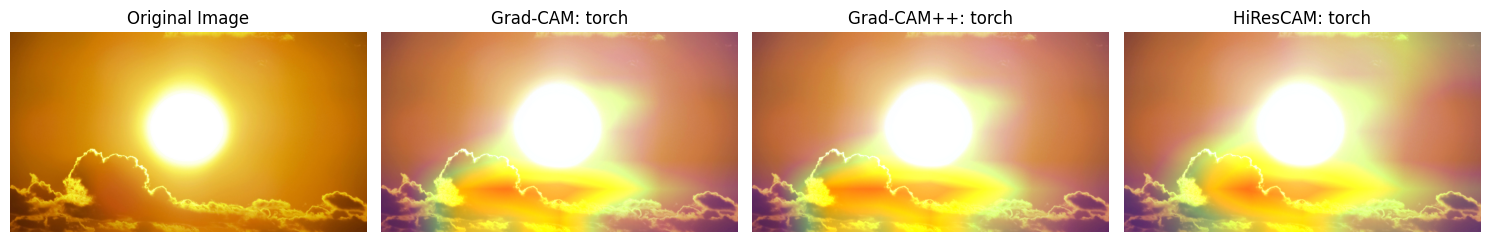


--- Analyzing: Traffic Light ---


HTTPError: 404 Client Error: Not Found for url: https://images.pexels.com/photos/53230/traffic-light-traffic-sign-red-stop-53230.jpeg

In [ ]:

# Used gemini to enhance code
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt


def get_model_and_target_layer(model_name='resnet50'):

    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        target_layer = model.layer4[-1]
    elif model_name == 'vgg19':
        model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        target_layer = model.features[-1]
    else:
        raise ValueError("Model not supported. Choose 'resnet50' or 'vgg19'")

    model.eval()
    return model, target_layer

def preprocess_image(image_path_or_url):
    if image_path_or_url.startswith('http'):
        response = requests.get(image_path_or_url, stream=True)
        response.raise_for_status()
        image = Image.open(response.raw).convert('RGB')
    else:
        image = Image.open(image_path_or_url).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = preprocess(image)
    return input_tensor.unsqueeze(0), image

class GradCAM:
    """
    Implements Grad-CAM to generate a heatmap for a specific class.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _hook_forward(self, module, input, output):
        self.activations = output.detach()

    def _hook_backward(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def _register_hooks(self):
        self.target_layer.register_forward_hook(self._hook_forward)
        self.target_layer.register_full_backward_hook(self._hook_backward)

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output).item()

        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        pooled_gradients = torch.mean(self.gradients, dim=[2, 3])
        weights = pooled_gradients[0]

        for i in range(weights.size(0)):
             self.activations[0, i, :, :] *= weights[i]

        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

class GradCAMpp(GradCAM):
    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output).item()

        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        grads = self.gradients
        activations = self.activations
        score = output[0][class_idx]
        first_derivative = torch.exp(score) * grads
        second_derivative = first_derivative * grads
        third_derivative = second_derivative * grads

        global_sum = torch.sum(activations, dim=(2, 3), keepdim=True)

        alpha_num = second_derivative
        alpha_denom = 2 * second_derivative + third_derivative.mul(global_sum)
        alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))

        alphas = alpha_num / alpha_denom

        weights = torch.sum(F.relu(grads * alphas), dim=(2, 3))

        weighted_activations = torch.zeros_like(activations[0, 0, :, :])
        for i in range(weights.size(1)):
            weighted_activations += weights[0, i] * activations[0, i, :, :]

        heatmap = F.relu(weighted_activations)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy(), class_idx


class HiResCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.target_layer.register_forward_hook(self._hook_forward)

    def _hook_forward(self, module, input, output):
        self.activations = output

    def generate_heatmap(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output).item()


        weights = self.activations
        x = self.activations


        tail = nn.Sequential(self.model.avgpool, nn.Flatten(), self.model.fc)


        scores = []
        for i in range(weights.shape[1]):

            temp_activations = torch.zeros_like(x)
            temp_activations[0, i, :, :] = x[0, i, :, :]


            score = tail(temp_activations)
            scores.append(score[0, class_idx])

        elementwise_weights = torch.tensor(scores, device=x.device).view(1, -1, 1, 1)


        heatmap = torch.sum(elementwise_weights * self.activations, dim=1).squeeze()

        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy(), class_idx




def show_cam(image, heatmap, title):
    heatmap_resized = cv2.resize(heatmap, (image.size[0], image.size[1]))
    heatmap_normalized = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_normalized), cv2.COLORMAP_JET)


    original_image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)


    superimposed_img = heatmap_colored * 0.4 + original_image_cv
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)


    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    plt.imshow(superimposed_img_rgb)
    plt.title(title)
    plt.axis('off')



if __name__ == '__main__':

    MODEL_NAME = 'resnet50'

    IMAGE_URLS = {
        "Stop Sign": "https://images.pexels.com/photos/301599/pexels-photo-301599.jpeg",
        "Traffic Light": "https://images.pexels.com/photos/53230/traffic-light-traffic-sign-red-stop-53230.jpeg",
        "Pedestrian": "https://images.pexels.com/photos/1612845/pexels-photo-1612845.jpeg",
        "Misleading Sign": "https://i.ebayimg.com/images/g/cQMAAOSwYSlk~YkY/s-l1600.jpg",
        "Zebra": "https://images.pexels.com/photos/1424538/pexels-photo-1424538.jpeg"
    }


    try:
        response = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
        labels = [line.strip() for line in response.text.split('\n')]
    except Exception as e:
        print(f"Could not load ImageNet labels: {e}")
        labels = None


    for name, url in IMAGE_URLS.items():
        print(f"\n--- Analyzing: {name} ---")

        input_tensor, original_image = preprocess_image(url)
        model, target_layer = get_model_and_target_layer(MODEL_NAME)


        grad_cam = GradCAM(model, target_layer)
        grad_cam_pp = GradCAMpp(model, target_layer)
        hires_cam = HiResCAM(model, target_layer)


        heatmap_gc, class_idx = grad_cam.generate_heatmap(input_tensor)
        heatmap_gcpp, _ = grad_cam_pp.generate_heatmap(input_tensor, class_idx)
        heatmap_hr, _ = hires_cam.generate_heatmap(input_tensor, class_idx)

        pred_label = labels[class_idx] if labels else f"Class {class_idx}"
        print(f"Model Prediction: {pred_label}")

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(original_image)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 4, 2)
        show_cam(original_image, heatmap_gc, f'Grad-CAM: {pred_label}')

        plt.subplot(1, 4, 3)
        show_cam(original_image, heatmap_gcpp, f'Grad-CAM++: {pred_label}')

        plt.subplot(1, 4, 4)
        show_cam(original_image, heatmap_hr, f'HiResCAM: {pred_label}')

        plt.tight_layout()
        plt.show()


